# Autoregressive Models

In this practical, we'll go over the following topics:
- Autoregressive models and when to use them
- Implementing equivariances in Autoregressive GNNs
- Evaluating scientific AI models

But first, a short introduction on the dataset used for this practical.

![Boids gif](figures/boids.gif)

## Boids (by Craig Reynolds)

The Boids algorithm, developed by Craig Reynolds [2], aims to replicate the behavior of flocking birds. 

The simplest setting, used in this practical, follows three simple rules:

1. Separation: Each boid should steer away from crowding local flockmates (avoiding collisions)
2. Alignment: Each boid should steer towards the average heading of local flockmates
3. Cohesion: Each boid should steer towards the average position of local flockmates

With some parameter tuning, these rules allow for some surprisingly realistic behavior. A gif of one of the simulations is shown above.

### Implementation details

Our dataset consists of 1000 samples of Boids simulations. Each simulation has 25 Boids and continues for 1000 timesteps. The Boids fly around in a 2D grid of 1000 x 1000 units.

In our simulations, Boids steer away from eachother (Separation) if they are within 16 units of eachother. Boids steer towards the average heading/position of all (local) flockmates within 40 units.*
Finally, we use periodic boundary conditions; Boids cannot leave the screen, they re-enter on the other side (pacman style).

* We use Euclidean distance (with PBC) here to compute the distance between boids. For a more detailed explanation, visit [The minimum image convention](https://en.wikibooks.org/wiki/Molecular_Simulation/Periodic_Boundary_Conditions) section of the wikibooks page on PBC.

## Problem setting

Boids simulations feature complex interactions between multiple actors (nodes). The simulation can be chaotic and very sensitive to initial conditions. 


This makes it an interesting playground for the models/frameworks discussed in the course. In this practical, we will implement an AR model from scratch, then gradually introduce equivariances and training/evaluation methods.


In [1]:
import torch 
import torch_geometric
from torch_geometric.data import Data, DataLoader, InMemoryDataset
import numpy as np
import matplotlib.pyplot as plt
import os

## Data exploration

First let's look at the data structure, and some statistics.

In [2]:
trajectories = [np.load(f"../../data/boids/raw/{f}") for f in os.listdir("../../data/boids/raw") if f.endswith(".npy")]
print(len(trajectories))

26


In [3]:
print("Single trajectory shape:")
print(trajectories[0].shape)
print("The axes and their cardinalities; (Timesteps:1000, Boids:25, (Position X, Position Y, Velocity x, Velocity y):4)")

Single trajectory shape:
(1000, 25, 4)
The axes and their cardinalities; (Timesteps:1000, Boids:25, (Position X, Position Y, Velocity x, Velocity y):4)


In [4]:
# Print the mean, std, min and max of the boid positions, velocities
positions = np.array([t[:, :, :2] for t in trajectories])
velocities = np.array([t[:, :, 2:] for t in trajectories])

print("Position mean, std, min, max:")
# Round to 2 decimal places
print(round(np.mean(positions),2), round(np.std(positions),2), round(np.min(positions), 2), round(np.max(positions), 2))
print()
print("Velocity mean, std, min, max:")
# Round to 2 decimal places
print(round(np.mean(velocities),2), round(np.std(velocities),2), round(np.min(velocities), 2), round(np.max(velocities), 2))

Position mean, std, min, max:
500.32 290.61 0.0 1000.0

Velocity mean, std, min, max:
-0.35 2.96 -6.0 6.0


In [5]:
def plot_state(trajectory, timestep):
    fig, ax = plt.subplots()
    # Plot dots for the boids
    ax.scatter(trajectory[timestep, :, 0], trajectory[timestep, :, 1])
    # plot the boid velocities as arrows
    for i in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        ax.arrow(trajectory[timestep, i, 0], trajectory[timestep, i, 1], trajectory[timestep, i, 2]*5, trajectory[timestep, i, 3]*5)
    return ax

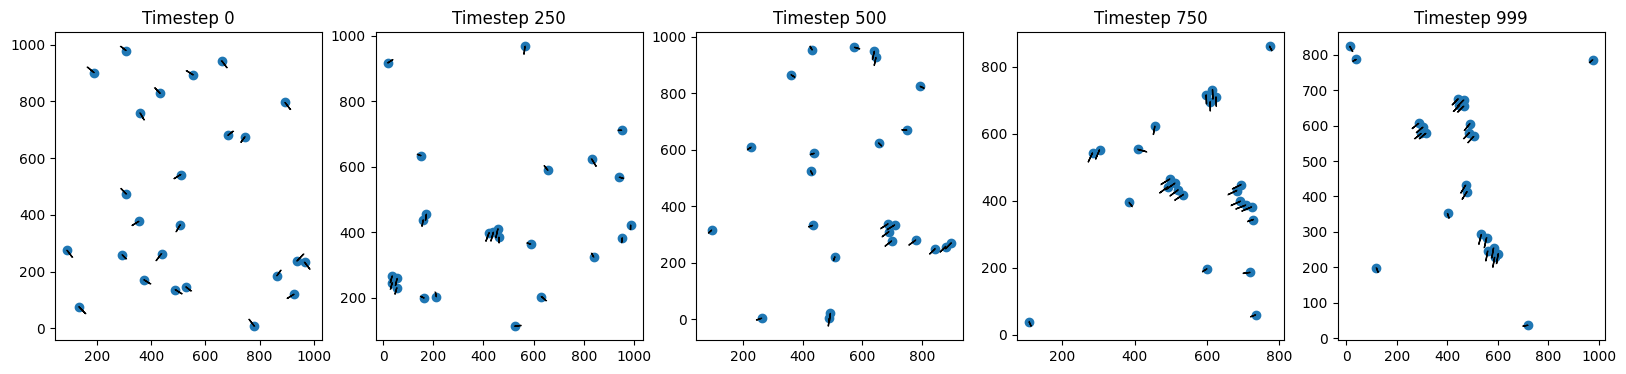

In [6]:
# Plot timesteps 0, 250, 500, 750, 999 for the first trajectory
trajectory = trajectories[0]
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, t in enumerate([0, 250, 500, 750, 999]):
    axs[i].set_title(f"Timestep {t}")
    # Plot dots for the boids
    axs[i].scatter(trajectory[t, :, 0], trajectory[t, :, 1])
    # plot the boid velocities as arrows
    for j in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        axs[i].arrow(trajectory[t, j, 0], trajectory[t, j, 1], trajectory[t, j, 2]*5, trajectory[t, j, 3]*5)
plt.show()

In the plot above, you can see that after some warmup time, the boids start to form flocks. Flocking behavior is a form of inter-node communication, which we will come back to again later.

Thinking back to the Geometric Deep Learning framework, we can identify the following symmetries in the data:

- The boids are equivariant to permutations, ie it does not matter in which order we compute the update rules for the boids.
- Local flocks of boids are equivariant to translation, rotation and reflection. 

Following these symmetries, it makes sense to model the boids using a Graph Neural Network (GNN). Specifically, since we are dealing with inter-node communication, we will be implementing a Message Passing GNN here.

But first, we create a `torch_geometric` InMemoryDataset object, to model the data as a graph.

In [7]:
class AR_Boids_Dataset(InMemoryDataset):
    def __init__(self, raw_data_path, processed_data_path, root=None, transform=None, pre_transform=None, post_transform=None, solution_idx_range=(0, 25), timesteps=1000, processed_file_name="AR1_Boids.pt"):
        self.raw_data_path = raw_data_path
        self.processed_data_path = processed_data_path
        self.solution_idx_range = solution_idx_range
        self.timesteps = timesteps
        self.processed_file_name = processed_file_name
        self.pre_transform = pre_transform
        self.transform = transform
        self.post_transform = post_transform
        super(AR_Boids_Dataset, self).__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def processed_file_names(self):
        return [self.processed_file_name]

    @property
    def raw_file_names(self):
        return [pfn for pfn in os.listdir(self.raw_data_path) if (self.solution_idx_range[0] <= int(pfn.split("_")[-1][:-4]) < self.solution_idx_range[1])]
    
    def download(self):
        pass
    
    def __len__(self):
        return (self.timesteps - 1) * (self.solution_idx_range[1] - self.solution_idx_range[0])

    def process(self):
        data_list = []
        for idx, raw_path in enumerate(self.raw_file_names):
            trajectory = np.load(self.raw_data_path + raw_path)

            if self.transform is not None:
                trajectory = self.transform(trajectory)

            for t in range(trajectory.shape[0] - 1):
                x = torch.tensor(trajectory[t], dtype=torch.float)
                y_temp = torch.tensor(trajectory[t+1], dtype=torch.float)
                # y_temp is (position x, position y, velocity x, velocity y) for the next timestep
                # However, we want delta position and delta velocity
                # Luckily, the delta poisition is just the velocity from the next timestep, and the delta velocity is the acceleration
                # So we can just take the last two elements of y to get the delta velocity
                # First we copy the last two columns of y to the first two columns of y
                y = y_temp.clone()
                y[:, :2] = y_temp[:, 2:]
                # Then we calculate the acceleration
                y[:, 2:] = y_temp[:, 2:] - x[:, 2:]    # (V_x ^ (t+1), V_y ^ (t+1), a_x, a_y)

                # fully connected graph
                edge_index = torch.tensor([[i, j] for i in range(trajectory.shape[1]) for j in range(trajectory.shape[1]) if i != j], dtype=torch.long).t().contiguous()
    
                if self.post_transform is not None:
                    data = self.post_transform(data)
                
                data = Data(x=x, y=y, edge_index=edge_index)
                data_list.append(data)
        data, slices = self.collate(data_list)
        torch.save((data, slices), self.processed_data_path+self.processed_file_name)

    def __getitem__(self, idx):
        return self.get(idx)
    
    def __repr__(self):
        return f'{self.__class__.__name__}({len(self)})'

In [8]:
train_dataset = AR_Boids_Dataset(raw_data_path="../../data/boids/raw/", processed_data_path="../../data/boids/processed/", root="../../data/boids/", solution_idx_range=(0, 15), timesteps=1000, processed_file_name="AR1_Boids.pt")
validation_dataset = AR_Boids_Dataset(raw_data_path="../../data/boids/raw/", processed_data_path="../../data/boids/processed/", root="../../data/boids/", solution_idx_range=(16, 25), timesteps=1000, processed_file_name="AR1_VAL_Boids.pt")

print(train_dataset)
print(validation_dataset)


data_0 = train_dataset[0]
print(data_0)
print(data_0.keys)
print("Pos x, Pos y, Vel x, Vel y")
print(data_0.x[0,:])

AR_Boids_Dataset(14985)
AR_Boids_Dataset(8991)
Data(x=[25, 4], edge_index=[2, 600], y=[25, 4])
<bound method BaseData.keys of Data(x=[25, 4], edge_index=[2, 600], y=[25, 4])>
Pos x, Pos y, Vel x, Vel y
tensor([864., 185.,   3.,   4.])


## Autoregressive Models
In general, when dealing with simulations spanning multiple timesteps, we can define the learning problem as follows.

Let $X^{0:T-1}$ denote the states spanning across timesteps $t=0$ through $t=T-1$. Given the initial state $X^0$, our goal is to accurately predict the future states $X^{1:T-1}$. In the probabilistic case, we want to learn a model with parameters $\theta$ for the probability distribution $P_\theta(X^{1:T-1}|X^0)$.*

In some systems, such as in the Boids setting, the next state X^{t+1} is only dependent on the current state X^t. Such systems are memoryless, and are often said to be _Markovian_. The Markov property allows us to rewrite the learning task to $P_\theta(X^{1:T-1}|X^0) = \prod_{t=0}^{T-2} P_\theta(X^{t+1} | X^t)$

Here, $P_\theta(X^{t+1} | X^t)$ is the _Autoregressive model_ - literally meaning it is used to autoregressively construct the full trajectory of the system. Note that this model is autoregressive in time; not space.

*: In this practical, we will not be building a probabilistic model. So instead of parameterizing a distribution, we learn a function $f_\theta: X^t \rarr X^{t+1}$.

### Autoregressive set model

Below, we create the simplest AR model for the Boids system; a fully connected GNN (essentially a set model).

Given a fully connected graph $X^t$, representing the Boids system at time $t$; it learns to predict the next state of the system $X^{t+1}$.

Note here that we use all features from the dataset as node features. This causes the model to not be equivariant to some group actions, that are relevant in the Boids setting.

---

Tick the equivariance(s) of this model:

- <input
      type="checkbox"
      id="eq0"
      name="perm"
      value="perm" />
    <label for="eq1">Permutational Equivariance</label>

- <input
      type="checkbox"
      id="eq1"
      name="space"
      value="space" />
    <label for="eq1">Space Translation Equivariance</label>

- <input
      type="checkbox"
      id="eq2"
      name="time"
      value="time" />
    <label for="eq2">Time Translation Equivariance</label>

- <input
      type="checkbox"
      id="eq3"
      name="rot"
      value="rot" />
    <label for="eq3">Rotation/Reflection Equivariance</label>

In [9]:
class AR_Set_Model(torch.nn.Module):
    def __init__(self, node_dim=4, emb_dim=16, out_dim=4):
        super(AR_Set_Model, self).__init__()
        self.node_embedding = torch.nn.Linear(node_dim, emb_dim)
        self.conv1 = torch_geometric.nn.GCNConv(emb_dim, emb_dim)
        self.conv2 = torch_geometric.nn.GCNConv(emb_dim, out_dim)
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.node_embedding(x)
        x = torch.nn.functional.relu(x)
        x = self.conv1(x, edge_index)
        x = torch.nn.functional.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [10]:
class Trainer:
    def __init__(self, model, train_dataset, validation_dataset, batch_size=1, lr=0.0001, epochs=100, loss_fn=torch.nn.MSELoss(), model_name= "01-AR-Set-Model.pt"):
        """
        Simple Trainer class to train a PyTorch (geometric) model on a dataset.

        Args:
            model: PyTorch model to train
            train_dataset: PyTorch dataset to train on
            validation_dataset: PyTorch dataset to validate on
            batch_size: Batch size for training
            lr: Learning rate
            epochs: Number of epochs to train for
            loss_fn: Loss function to use
        """
        self.model = model
        self.train_dataset = train_dataset
        self.validation_dataset = validation_dataset
        self.batch_size = batch_size
        self.lr = lr
        self.epochs = epochs
        self.loss_fn = loss_fn
        self.model_name = model_name

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print("Using device:", self.device)
        self.model.to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)

        self.train_loader = self.make_data_loader(self.train_dataset)
        self.validation_loader = self.make_data_loader(self.validation_dataset, shuffle=False)

    def make_data_loader(self, dataset, shuffle=True):
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle)

    def train_loop(self):
        """
        Train loop for the model
        """
        best_model_loss = np.inf
        for epoch in range(self.epochs):
            # Train the model
            self.model.train()
            mean_train_loss = 0
            for i, data in enumerate(self.train_loader):
                data = self.train_dataset[i].to(self.device)
                self.optimizer.zero_grad()
                out = self.model(data)
                loss = self.loss_fn(out, data.y)
                loss.backward()
                self.optimizer.step()
                mean_train_loss += loss.item()
            mean_train_loss /= i
            
            # Validate the model
            self.model.eval()
            mean_val_loss = 0
            with torch.no_grad():
                for i, data in enumerate(self.validation_loader):
                    data = self.validation_dataset[i].to(self.device)
                    out = self.model(data)
                    loss = self.loss_fn(out, data.y)
                    mean_val_loss += loss.item()
                mean_val_loss /= i

            if mean_val_loss < best_model_loss:
                best_model_loss = mean_val_loss
                torch.save(self.model.state_dict(), f"../../models/{self.model_name}")
            
            print(f"Epoch {epoch}, Mean Train Loss: {mean_train_loss}, Mean Validation Loss: {mean_val_loss}")



In [11]:
model = AR_Set_Model(emb_dim=64)
trainer = Trainer(model, train_dataset, validation_dataset, batch_size=8, loss_fn=torch.nn.MSELoss(), epochs=100, model_name="01-AR-Set-Model.pt")
trainer.train_loop()

Using device: cuda


/home/seppe/tue/atai-2025/.venv/lib/python3.12/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


KeyboardInterrupt: 

### Q1: Implementing rollout code

We have a working model now to predict $\hat{X}^{t+1}$ given $X^t$. However, we of course want to be able to generate trajectories longer than one step (ie for i steps: $\hat{X}^{t+1:t+i}$), given $X^t$.

We sometimes call this a `rollout` - essentially a multi-step prediction.

Q1: Complete the method below, which generates a rollout of `timesteps` steps, for a given model `model`, and dataset `dataset` *.

HINT: What should happen if the position $x_i, y_i$ of boid $i$ are predicted to move $dx_i, dy_i$, such that $x_i + dx_i > \text{width}$ or $y_i + dy_i > \text{height}$?

*: If you check the cell below the next cell, we already made a dataset for you that only contains initial positions :)

In [12]:
def compute_ar_set_model_rollouts(model, dataset, timesteps=1000, device='cuda', mode="residual", width = 1000, height = 1000):
    """
    Predict the rollouts of the model on the dataset starting from the idx

    Args:
        model: PyTorch model
        dataset: PyTorch dataset
        timesteps: Number of timesteps to predict
        device: Device to run the model on
        mode: "residual" or "direct"
        - In the solution above, we used the "residual" mode, where the model predicts the change in position and velocity
        - In the "direct" mode, the model predicts the position and velocity directly (if you do not intend to use this mode, you can ignore this argument)
        width: Width of the PBC box
        height: Height of the PBC box
    Returns:
        rollouts: Rollouts of the model on the dataset
        - Should be a torch tensor of shape (Batch, Timesteps, Boids, Node_dim)
    """
    rollouts = torch.empty((len(dataset), timesteps, dataset[0].x.shape[0], dataset[0].x.shape[1]), device=device)

    model.eval()
    with torch.no_grad():
        for idx, init_data in enumerate(dataset):
            # Get the initial state
            model_data = init_data.clone().to(device)

            for t in range(timesteps):
                out_data = model(model_data)

                # Update
                if mode == "direct":
                    model_data.x = out_data
                elif mode == "residual":
                    model_data.x += out_data

                # Wrap around the positions
                model_data.x[:, 0] = model_data.x[:, 0] % width
                model_data.x[:, 1] = model_data.x[:, 1] % height

                # Store the current state
                rollouts[idx, t] = model_data.x.clone().cpu()

    return rollouts

In [ ]:
def keep_01(data):
    return data[0:2, :, :]

initial_states_validation_dataset = AR_Boids_Dataset(
    raw_data_path="../../data/boids/raw/", 
    processed_data_path="../../data/boids/processed/", 
    root="../../data/boids/", 
    solution_idx_range=(16, 25), 
    timesteps=2, 
    processed_file_name="AR1_VAL_init.pt",
    transform=keep_01
    )

ar_set_model = AR_Set_Model(emb_dim=64)
ar_set_model.load_state_dict(torch.load("../../models/01-AR-Set-Model.pt"))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
ar_set_model.to(device)
ar_set_model.eval()

ar_set_model_rollout = compute_ar_set_model_rollouts(ar_set_model, initial_states_validation_dataset, timesteps=1000, device=device)

We'll evaluate these rollouts later.

In [13]:
from matplotlib import animation

# TODO: Implemented this myself to see whether I did it correctly
def animate_rollout(rollouts, output_path="output/rollout.gif", width = 1000, height = 1000, max_timesteps=100):
    # rollouts of shape (Timesteps, Boids, Node_dim)
    
    # Create output directory if it does not exist
    os.makedirs(os.path.dirname(output_path), exist_ok=True)

    # Parse rollouts
    timesteps, num_boids, node_dim = rollouts.shape
    rollouts = rollouts.cpu().numpy()

    # Initialize the figure and axis
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(1, 1, 1)

    quiv = ax.quiver(rollouts[0, :, 0], rollouts[0, :, 1], rollouts[0, :, 2], rollouts[0, :, 3])
    scat = ax.scatter(rollouts[0, :, 0], rollouts[0, :, 1])
    ax.set_xlim(0, width)
    ax.set_ylim(0, height)
    ax.set_aspect('equal', adjustable='box')

    def update(frame):
        quiv.set_offsets(rollouts[frame, :, :2])
        quiv.set_UVC(rollouts[frame, :, 2], rollouts[frame, :, 3])
        scat.set_offsets(rollouts[frame, :, :2])
        return scat, quiv

    ani = animation.FuncAnimation(fig, update, frames=min(timesteps, max_timesteps), blit=False, interval=150)
    ani.save(output_path, writer="ffmpeg")
    plt.close()

In [ ]:
from IPython.display import Image

animate_rollout(ar_set_model_rollout[0])
Image(filename="output/rollout.gif")

### Quick recap on equivariances

<img src="figures/boids-translational-equivariance.png" alt="drawing" width="250" style="background-color: white; padding: 50px;"/>
<img src="figures/boids-rotational-equivariance.png" alt="drawing" width="250" style="background-color: white; padding: 50px;"/>

The figures above show the equivariances of the Boids system. The system is equivariant to all E(n) transformations; translation,
rotation and reflection.*

Formally, we say a function $f: X \rarr Y$ is _equivariant_ to a group action or transformation $T: X \rarr X$ if there is an equivalent transformation $S: Y \rarr Y$ on the output space of the function such that

$f(T(x)) = S(f(x))$ for each $x \in X$

We won't go into the formal definitions of each equivariance, but if you're interested you can check out the [E(n) Equivariant Graph Neural Networks](https://arxiv.org/pdf/2102.09844) paper [3], the equivariant model is based on. 

*: Excluding time translation equivariance, which states that there is no dependence on the time of the system, only the state.

*: Also excluding permutational equivariance; the order of the nodes does not matter.

## Towards Equivariant AR-GNNs
The above model is **not** equivariant to translations in space! This is because we use absolute coordinates as _node features_, which creates a dependence on the absolute coordinate system. Instead, if we do not use the absolute positions as node features - and include the PBC distance as _edge features_ - the predictions will be space translation equivariant.

Let's implement this!

Before, we were not using the fact that boids only affect eachother within a certain radius, since we used a fully connected graph without edge weights.

Before blindly jumping into the new dataset code, let's investigate this behavior.

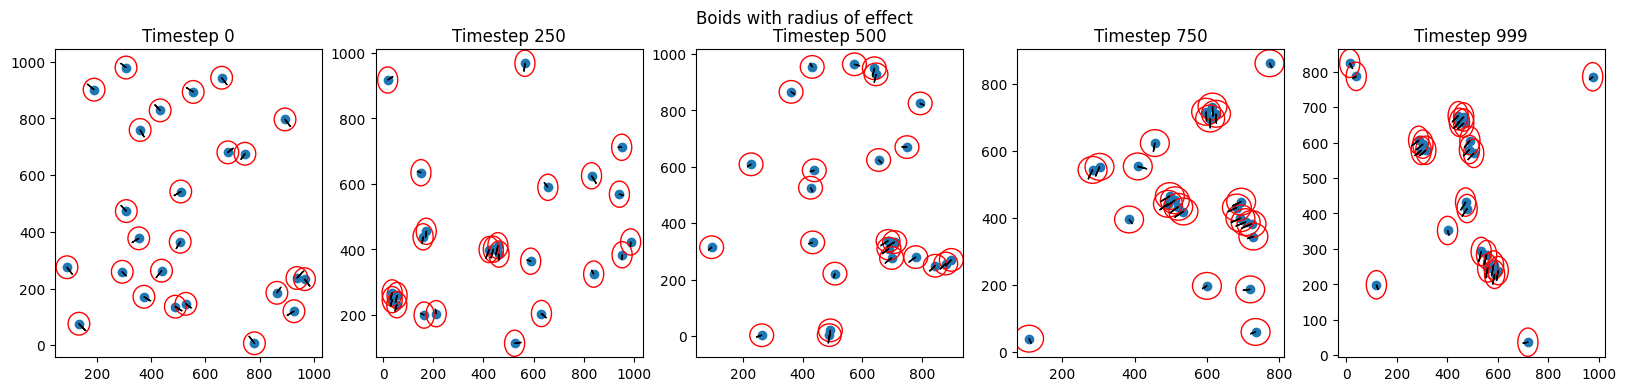

In [14]:
# Plot timesteps 0, 250, 500, 750, 999 for the first trajectory
trajectory = trajectories[0]
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Boids with radius of effect")
radius = 40

for i, t in enumerate([0, 250, 500, 750, 999]):
    axs[i].set_title(f"Timestep {t}")
    # Plot dots for the boids
    axs[i].scatter(trajectory[t, :, 0], trajectory[t, :, 1])
    # Draw a red circle around each boid to indicate the radius
    for j in range(trajectory.shape[1]):
        circle = plt.Circle((trajectory[t, j, 0], trajectory[t, j, 1]), radius, color='r', fill=False)
        axs[i].add_artist(circle)
    # plot the boid velocities as arrows
    for j in range(trajectory.shape[1]):
        # NOTE: The arrows are made larger for effect
        axs[i].arrow(trajectory[t, j, 0], trajectory[t, j, 1], trajectory[t, j, 2]*5, trajectory[t, j, 3]*5)
plt.show()

## Q2 E(n) Equivariant Graph Neural Networks

In Satorras, Hoogeboom, Welling's paper [3] with the same name, they introduce a relatively simple model that is equivariant to E(n) transformations. You can check the official implementation. implement the E(n)-Equivariant Graph Neural Networks (EGNN) model from scratch.


You're absolutely right! The standard `GCNConv` is too limiting for EGNN. We need custom message computation that includes distance information and separate handling of position updates. Let's implement this using PyTorch Geometric's `MessagePassing` class:

Implement the push-forward training mechanism for the AR-Set-Model and the EGNN developed in Q2

We first add a timer class that will allow us to determine where time is being spent.

In [ ]:
from collections import defaultdict
from contextlib import contextmanager

class HierarchicalTimer:
    """
    A timer that supports nested timing contexts with hierarchical tracking.
    
    Usage:
        timer = HierarchicalTimer()
        
        with timer.time("training"):
            with timer.time("data_loading"):
                # data loading code
                pass
            with timer.time("forward_pass"):
                # forward pass code
                pass
                
        timer.print_timings()
        timer.reset()
    """
    
    def __init__(self):
        self.timings = defaultdict(float)  # Flat storage: "key1.key2.key3" -> total_time
        self.counts = defaultdict(int)     # How many times each key was called
        self.stack = []                    # Current timing stack
        self.start_times = {}              # Start time for each active timing
        
    @contextmanager
    def time(self, key):
        """Context manager for timing a section of code"""
        # Build hierarchical key
        full_key = ".".join(self.stack + [key])
        
        # Start timing
        self.stack.append(key)
        start_time = time.time()
        self.start_times[full_key] = start_time
        
        try:
            yield
        finally:
            # End timing
            end_time = time.time()
            elapsed = end_time - start_time
            
            self.timings[full_key] += elapsed
            self.counts[full_key] += 1
            
            # Clean up
            if full_key in self.start_times:
                del self.start_times[full_key]
            self.stack.pop()
    
    def print_timings(self, min_time=0.001, show_tree=True):
        """Print timings in a hierarchical format"""
        if not self.timings:
            print("No timings recorded.")
            return
        
        if show_tree:
            self._print_tree_format(min_time)
        else:
            self._print_level_format(min_time)
    
    def _print_tree_format(self, min_time=0.001):
        """Print timings in a tree format"""
        print("\n" + "="*80)
        print("HIERARCHICAL TIMING REPORT (Tree View)")
        print("="*80)
        
        # Build tree structure
        tree = {}
        for key, total_time in self.timings.items():
            if total_time >= min_time:
                parts = key.split('.')
                current = tree
                for part in parts:
                    if part not in current:
                        current[part] = {'_children': {}, '_time': 0, '_count': 0}
                    current = current[part]['_children']
                # Store timing info at the leaf
                leaf = tree
                for part in parts[:-1]:
                    leaf = leaf[part]['_children']
                leaf[parts[-1]]['_time'] = total_time
                leaf[parts[-1]]['_count'] = self.counts[key]
        
        # Print tree recursively
        def print_node(node_dict, prefix="", is_last=True):
            items = list(node_dict.items())
            for i, (key, value) in enumerate(items):
                is_last_item = (i == len(items) - 1)
                
                # Current prefix for this line
                current_prefix = "└── " if is_last_item else "├── "
                
                # Format timing info
                time_val = value['_time']
                count_val = value['_count']
                if time_val > 0:
                    avg_time = time_val / count_val if count_val > 0 else 0
                    timing_info = f"{time_val:8.4f}s total | {avg_time:8.4f}s avg | {count_val:4d} calls"
                    print(f"{prefix}{current_prefix}{key:<25} | {timing_info}")
                else:
                    print(f"{prefix}{current_prefix}{key}")
                
                # Prepare prefix for children
                if value['_children']:
                    child_prefix = prefix + ("    " if is_last_item else "│   ")
                    print_node(value['_children'], child_prefix, is_last_item)
        
        print_node(tree)
        
        # Calculate total time
        total_time = sum(time for key, time in self.timings.items() if '.' not in key)
        print("-" * 80)
        print(f"TOTAL TOP-LEVEL TIME: {total_time:.4f}s")
        print("="*80)
    
    def _print_level_format(self, min_time=0.001):
        """Print timings grouped by hierarchy level (original format)"""
        # Group by hierarchy level
        by_level = defaultdict(list)
        for key, total_time in self.timings.items():
            if total_time >= min_time:  # Filter out very small timings
                level = key.count('.')
                by_level[level].append((key, total_time))
        
        # Sort each level by time (descending)
        for level in by_level:
            by_level[level].sort(key=lambda x: x[1], reverse=True)
        
        print("\n" + "="*60)
        print("HIERARCHICAL TIMING REPORT (Level View)")
        print("="*60)
        
        # Print level by level
        for level in sorted(by_level.keys()):
            if level == 0:
                print(f"\nTOP-LEVEL TIMINGS:")
            else:
                print(f"\nLEVEL {level + 1} TIMINGS:")
            print("-" * 40)
            
            for full_key, total_time in by_level[level]:
                count = self.counts[full_key]
                avg_time = total_time / count if count > 0 else 0
                
                # Extract just the current level key for display
                key_parts = full_key.split('.')
                current_key = key_parts[-1]
                
                # Show parent context for deeper levels
                if level > 0:
                    parent_key = ".".join(key_parts[:-1])
                    print(f"  {current_key:20s} | {total_time:8.4f}s total | {avg_time:8.4f}s avg | {count:4d} calls | under: {parent_key}")
                else:
                    print(f"  {current_key:20s} | {total_time:8.4f}s total | {avg_time:8.4f}s avg | {count:4d} calls")
        
        print("-" * 60)
        total_time = sum(time for key, time in self.timings.items() if '.' not in key)
        print(f"TOTAL TOP-LEVEL TIME: {total_time:.4f}s")
        print("="*60)
    
    def print_summary(self, max_items=10):
        """Print a concise summary of the top time consumers"""
        if not self.timings:
            print("No timings recorded.")
            return
        
        print("\n" + "="*60)
        print("TIMING SUMMARY - Top Time Consumers")
        print("="*60)
        
        # Sort all timings by total time
        sorted_timings = sorted(self.timings.items(), key=lambda x: x[1], reverse=True)
        
        for i, (key, total_time) in enumerate(sorted_timings[:max_items]):
            count = self.counts[key]
            avg_time = total_time / count if count > 0 else 0
            # Show the full hierarchical path
            print(f"{i+1:2d}. {key:<40} | {total_time:8.4f}s total | {avg_time:8.4f}s avg | {count:4d} calls")
        
        if len(sorted_timings) > max_items:
            print(f"    ... and {len(sorted_timings) - max_items} more")
        
        print("="*60)
    
    def reset(self):
        """Reset all timings"""
        self.timings.clear()
        self.counts.clear()
        self.stack.clear()
        self.start_times.clear()
    
    def get_timing(self, key):
        """Get total time for a specific key"""
        return self.timings.get(key, 0.0)
    
    def get_breakdown(self, parent_key):
        """Get timing breakdown for all children of a parent key"""
        prefix = parent_key + "."
        children = {}
        for key, time_val in self.timings.items():
            if key.startswith(prefix):
                child_key = key[len(prefix):].split('.')[0]  # Get immediate child
                if child_key not in children:
                    children[child_key] = 0
                children[child_key] += time_val
        return children
    
    def print_breakdown(self, parent_key):
        """Print timing breakdown for a specific parent key"""
        breakdown = self.get_breakdown(parent_key)
        if not breakdown:
            print(f"No child timings found for '{parent_key}'")
            return
        
        total_parent_time = self.get_timing(parent_key)
        print(f"\nBreakdown for '{parent_key}' (total: {total_parent_time:.4f}s):")
        print("-" * 50)
        
        sorted_children = sorted(breakdown.items(), key=lambda x: x[1], reverse=True)
        for child_key, child_time in sorted_children:
            percentage = (child_time / total_parent_time * 100) if total_parent_time > 0 else 0
            print(f"  {child_key:<20} | {child_time:8.4f}s | {percentage:5.1f}%")
    
    def get_percentage_breakdown(self, parent_key):
        """Get percentage breakdown of child timings relative to parent"""
        breakdown = self.get_breakdown(parent_key)
        total_parent_time = self.get_timing(parent_key)
        
        if total_parent_time == 0:
            return {}
        
        return {child: (time_val / total_parent_time * 100) 
                for child, time_val in breakdown.items()}
    
    def print_averaged_timings(self, num_epochs, min_time=0.001):
        """Print timings averaged per epoch (excluding first epoch setup)"""
        if not self.timings:
            print("No timings recorded.")
            return
        
        print(f"\n=== AVERAGED TIMING OVER {num_epochs} EPOCHS ===")
        print("="*80)
        
        # Build tree structure with averaged times
        tree = {}
        for key, total_time in self.timings.items():
            if total_time >= min_time:
                # For epoch-level timings, divide by number of epochs
                if 'epoch' in key and not key.endswith('epoch'):
                    # This is a sub-timing of epochs, so average it
                    avg_time = total_time / num_epochs
                else:
                    avg_time = total_time / self.counts[key] if self.counts[key] > 0 else 0
                
                if avg_time >= min_time / num_epochs:  # Adjust threshold for averaged times
                    parts = key.split('.')
                    current = tree
                    for part in parts:
                        if part not in current:
                            current[part] = {'_children': {}, '_time': 0, '_count': 0}
                        current = current[part]['_children']
                    # Store timing info at the leaf
                    leaf = tree
                    for part in parts[:-1]:
                        leaf = leaf[part]['_children']
                    leaf[parts[-1]]['_time'] = avg_time
                    leaf[parts[-1]]['_count'] = self.counts[key] // num_epochs if 'epoch' in key else self.counts[key]
        
        # Print tree recursively
        def print_node(node_dict, prefix="", is_last=True):
            items = list(node_dict.items())
            for i, (key, value) in enumerate(items):
                is_last_item = (i == len(items) - 1)
                
                # Current prefix for this line
                current_prefix = "└── " if is_last_item else "├── "
                
                # Format timing info
                time_val = value['_time']
                count_val = value['_count']
                if time_val > 0:
                    timing_info = f"{time_val:8.4f}s avg/epoch | {count_val:4d} calls/epoch"
                    print(f"{prefix}{current_prefix}{key:<25} | {timing_info}")
                else:
                    print(f"{prefix}{current_prefix}{key}")
                
                # Prepare prefix for children
                if value['_children']:
                    child_prefix = prefix + ("    " if is_last_item else "│   ")
                    print_node(value['_children'], child_prefix, is_last_item)
        
        print_node(tree)
        print("="*80)


# Global timer instance
timer = HierarchicalTimer()

In [ ]:
class EGNNLayer(torch.nn.Module):
    """
    E(n) Equivariant Graph Neural Network Layer
    Based on Satorras et al. "E(n) Equivariant Graph Neural Networks"
    """
    
    def __init__(self, hidden_node_dim=64, hidden_edge_dim=32, width=1000.0, height=1000.0):
        super(EGNNLayer, self).__init__()
        
        # Periodic box sizes (for minimal image convention)
        self.width = float(width)
        self.height = float(height)
        
        # φ_e: Edge message function - takes [h_i, h_j, ||x_i - x_j||²]
        # Paper: Input → LinearLayer → Swish → LinearLayer → Swish → Output
        self.phi_e = torch.nn.Sequential(
            torch.nn.Linear(2 * hidden_node_dim + 1, hidden_edge_dim),
            torch.nn.SiLU(),  # SiLU is the same as Swish
            torch.nn.Linear(hidden_edge_dim, hidden_edge_dim),
            torch.nn.SiLU()
        )
        
        # φ_x: Coordinate weight function - takes edge message and outputs scalar
        # Paper: m_ij → LinearLayer → Swish → LinearLayer → Output
        self.phi_x = torch.nn.Sequential(
            torch.nn.Linear(hidden_edge_dim, hidden_edge_dim),
            torch.nn.SiLU(),  # SiLU is the same as Swish
            torch.nn.Linear(hidden_edge_dim, 1)
        )
        
        # φ_v: Velocity scaling function - takes node embedding and outputs velocity scale
        self.phi_v = torch.nn.Sequential(
            torch.nn.Linear(hidden_node_dim, hidden_node_dim),
            torch.nn.SiLU(),  # SiLU is the same as Swish
            torch.nn.Linear(hidden_node_dim, 2)  # Output 2D for velocity scaling
        )
        
        # φ_h: Node update function - takes [h_i, aggregate_messages]
        # Paper: [h_i, m_i] → LinearLayer → Swish → LinearLayer → Addition(h_i) → h_i^{l+1}
        # Note: We'll implement the residual connection in the forward pass
        self.phi_h = torch.nn.Sequential(
            torch.nn.Linear(hidden_node_dim + hidden_edge_dim, hidden_node_dim),
            torch.nn.SiLU(),  # SiLU is the same as Swish
            torch.nn.Linear(hidden_node_dim, hidden_node_dim)
        )
        
        
    def _minimal_image(self, delta, device):
        """Apply minimal image convention to 2D displacements under PBC."""
        half_sizes = torch.tensor([self.width / 2.0, self.height / 2.0], device=device, dtype=delta.dtype)
        sizes = torch.tensor([self.width, self.height], device=device, dtype=delta.dtype)
        return torch.remainder(delta + half_sizes, sizes) - half_sizes

        
    def forward(self, nodes, pos, vel_init, edge_index, trace_node_index=None):
        """
        Single EGNN layer forward pass
        
        Args:
            nodes: [N, hidden_node_dim] node embeddings
            pos: [N, 2] positions
            vel_init: [N, 2] initial velocities (preserved throughout all layers)
            edge_index: [2, E] edge connectivity
            
        Returns:
            nodes_new: [N, hidden_node_dim] updated node embeddings
            pos_new: [N, 2] updated positions
            vel_new: [N, 2] updated velocities (for this layer only)
        """
        with timer.time("egnn_layer"):
            N = nodes.shape[0]
            
            # Compute messages m_ij = φ_e(h_i, h_j, ||x_i - x_j||²)
            with timer.time("messages"):
                messages = self.compute_messages(nodes, pos, edge_index)
            
            # Compute φ_v(h_i)*v_i^{init} (always use initial velocities, not updated ones)
            vel_node_update = self.phi_v(nodes) * vel_init  # [N, 2]
            
            with timer.time("velocity_updates"):
                # Compute (1/N)*Σ_{j≠i}(x_i - x_j)*φ_x(m_ij)
                vel_message_update = self.compute_velocity_message_update(pos, messages, edge_index, N)
                # Update velocity: v_i^{l+1} = φ_v(h_i)*v_i^{init} + (1/N)*Σ_{j≠i}(x_i - x_j)*φ_x(m_ij)
                vel_new = vel_node_update + vel_message_update
                # Update position: x_i^{l+1} = x_i + v_i^{l+1}
                pos_new = pos + vel_new

                # Optional tracing for a specific node
                if trace_node_index is not None:
                    try:
                        idx = int(trace_node_index)
                        self._last_trace = {
                            "pos_in": pos[idx].detach().to("cpu"),
                            "vel_node_update": vel_node_update[idx].detach().to("cpu"),
                            "vel_message_update": vel_message_update[idx].detach().to("cpu"),
                            "vel_new": vel_new[idx].detach().to("cpu"),
                            "pos_out": pos_new[idx].detach().to("cpu"),
                        }
                    except Exception:
                        self._last_trace = None
            
            # Aggregate messages and update node embeddings
            with timer.time("node_updates"):
                aggregate_messages = self.aggregate_messages(messages, edge_index, N)
                # Apply phi_h and add residual connection as per paper
                node_update = self.phi_h(torch.cat([nodes, aggregate_messages], dim=1))
                nodes_new = nodes + node_update  # Residual connection: h_i^{l+1} = h_i^l + phi_h(...)
            
            return nodes_new, pos_new, vel_new
    
    def compute_messages(self, nodes, pos, edge_index):
        """
        Compute messages m_ij = φ_e(h_i, h_j, ||x_i - x_j||²)
        """
        edge_source_ids, edge_target_ids = edge_index  # [E] each
        
        # Get node features for each edge
        h_i = nodes[edge_target_ids]  # [E, hidden_node_dim] - target nodes
        h_j = nodes[edge_source_ids]  # [E, hidden_node_dim] - source nodes
        
        # Get positions for each edge
        pos_i = pos[edge_target_ids]  # [E, 2] - target positions
        pos_j = pos[edge_source_ids]  # [E, 2] - source positions
        
        # Compute minimal-image position differences
        pos_diff_ij = self._minimal_image(pos_i - pos_j, pos.device)  # [E, 2]
        
        # Compute distances ||x_i - x_j||
        dist_squared = (pos_diff_ij ** 2).sum(dim=1, keepdim=True)  # [E, 1]
        dist = torch.sqrt(dist_squared)  # [E, 1]
        dist_normalized = dist / 100.0  # [E, 1]

        # Create message input [h_i, h_j, ||x_i - x_j||²]
        message_input = torch.cat([h_i, h_j, dist_normalized], dim=1)  # [E, 2*hidden_node_dim + 1]
        # Compute messages
        messages = self.phi_e(message_input)  # [E, hidden_edge_dim]
        # Lightweight diagnostics
        try:
            self._last_messages_abs_mean = messages.detach().abs().mean()
        except Exception:
            self._last_messages_abs_mean = torch.tensor(0.0, device=messages.device)
        
        return messages
    
    def compute_velocity_message_update(self, pos, messages, edge_index, N):
        """
        Compute (1/N)*Σ_{j≠i}(x_i - x_j)*φ_x(m_ij)
        """
        edge_source_ids, edge_target_ids = edge_index  # [E] each
        
        # Get positions for each edge
        pos_i = pos[edge_target_ids]  # [E, 2] - target positions  
        pos_j = pos[edge_source_ids]  # [E, 2] - source positions
        
        # Compute minimal-image position differences (x_i - x_j)
        pos_diff = self._minimal_image(pos_i - pos_j, pos.device)  # [E, 2]
        
        # Compute coordinate weights φ_x(m_ij)
        coord_weights = self.phi_x(messages)  # [E, 1]
        
        # Diagnostics
        try:
            self._last_coord_weight_abs_mean = coord_weights.detach().abs().mean()
        except Exception:
            self._last_coord_weight_abs_mean = torch.tensor(0.0, device=pos.device)
        
        # Weighted position differences
        weighted_pos_diff = pos_diff * coord_weights  # [E, 2]
        
        # Aggregate by target nodes (sum over j for each i)
        vel_update = torch.zeros(N, 2, device=pos.device)
        vel_update.index_add_(0, edge_target_ids, weighted_pos_diff)
        # More diagnostics
        try:
            self._last_vel_update_norm_mean = vel_update.detach().norm(dim=1).mean()
        except Exception:
            self._last_vel_update_norm_mean = torch.tensor(0.0, device=pos.device)
        
        # Normalize by per-node in-degree (handles batched graphs correctly)
        degrees = torch.bincount(edge_target_ids, minlength=pos.size(0)).unsqueeze(1)
        vel_update = vel_update / degrees.clamp(min=1)
        
        return vel_update
    
    def aggregate_messages(self, messages, edge_index, N):
        """
        Aggregate messages: m_i = Σ_{j≠i} m_ij
        """
        edge_source_ids, edge_target_ids = edge_index
        
        # Aggregate messages by target nodes
        aggregate_messages = torch.zeros(N, messages.shape[1], device=messages.device)
        aggregate_messages.index_add_(0, edge_target_ids, messages)
        
        return aggregate_messages

In [ ]:
class EGNN(torch.nn.Module):
    """
    Full E(n) Equivariant Graph Neural Network for Boids
    """
    
    def __init__(self, hidden_node_dim=5, hidden_edge_dim=12, num_layers=4, num_nodes=25, width=1000.0, height=1000.0, weight_sharing=False):
        super(EGNN, self).__init__()
        
        # Store dims
        self.hidden_node_dim = hidden_node_dim
        self.num_layers = num_layers
        self.weight_sharing = weight_sharing
        
        # EGNN layers
        if self.weight_sharing:
            # Create a single shared layer and reference it num_layers times for logging consistency
            shared_layer = EGNNLayer(hidden_node_dim, hidden_edge_dim, width=width, height=height)
            self.layers = torch.nn.ModuleList([shared_layer for _ in range(num_layers)])
        else:
            self.layers = torch.nn.ModuleList([
                EGNNLayer(hidden_node_dim, hidden_edge_dim, width=width, height=height) 
                for _ in range(num_layers)
            ])
        
    def forward(self, data, trace_node_index=None):
        """
        Args:
            data: PyG data object with:
                - x: [N, 4] node features [pos_x, pos_y, vel_x, vel_y]
                - edge_index: [2, E] edge connectivity
        
        Returns:
            output: [N, 4] in format [pos_delta_x, pos_delta_y, vel_x_new, vel_y_new]
            
        Note: Output predicts position deltas and new velocities for balanced loss computation
        """
        with timer.time("egnn_forward"):
            # Extract features
            pos = data.x[:, :2]        # [N_total, 2] positions
            vel_init = data.x[:, 2:]   # [N_total, 2] initial velocities (preserved)

            # Initialize node embeddings simply as zeros; batching is handled implicitly by concatenation
            nodes = torch.zeros(pos.size(0), self.hidden_node_dim, device=pos.device)
            
            # Apply EGNN layers, always using the initial velocities
            self.last_layer_stats = []
            self.last_layer_traces = [] if trace_node_index is not None else None
            for i, layer in enumerate(self.layers):
                with timer.time(f"layer_{i}"):
                    nodes, pos, vel_current = layer(nodes, pos, vel_init, data.edge_index, trace_node_index=trace_node_index)
                    # Collect lightweight per-layer stats for visibility
                    stats = {
                        "messages_abs_mean": float(getattr(layer, "_last_messages_abs_mean", torch.tensor(0.0)).detach().item()),
                        "coord_weight_abs_mean": float(getattr(layer, "_last_coord_weight_abs_mean", torch.tensor(0.0)).detach().item()),
                        "vel_update_norm_mean": float(getattr(layer, "_last_vel_update_norm_mean", torch.tensor(0.0)).detach().item()),
                    }
                    self.last_layer_stats.append(stats)
                    if self.last_layer_traces is not None:
                        trace = getattr(layer, "_last_trace", None)
                        self.last_layer_traces.append(trace)
            
            # Calculate position delta from initial positions
            pos_delta = pos - data.x[:, :2]  # [N, 2] - difference from input positions
            
            # Return position deltas and final velocities for loss computation
            return torch.cat([pos_delta, vel_current], dim=1)  # [N, 4] - [pos_delta_x, pos_delta_y, vel_x, vel_y]


In [ ]:
class AR_EGNN_Dataset(InMemoryDataset):
    """
    Dataset for EGNN in the format:
    Input: [pos_x, pos_y, vel_x, vel_y]
    Output: [pos_delta_x, pos_delta_y, vel_x_new, vel_y_new] (position deltas and new velocities)
    
    Position deltas have similar magnitude to velocities, making loss contributions balanced.
    Node embeddings are learnable parameters in the model, not stored in the dataset.
    """
    def __init__(self, raw_data_path, processed_data_path, root=None, transform=None, pre_transform=None, post_transform=None, solution_idx_range=(0, 25), timesteps=1000, processed_file_name="AR1_EGNN_Boids.pt", hidden_node_dim=1, width=1000, height=1000):
        self.raw_data_path = raw_data_path
        self.processed_data_path = processed_data_path
        self.solution_idx_range = solution_idx_range
        self.timesteps = timesteps
        self.processed_file_name = processed_file_name
        self.hidden_node_dim = hidden_node_dim
        self.width = width
        self.height = height
        self.pre_transform = pre_transform
        self.transform = transform
        self.post_transform = post_transform
        super(AR_EGNN_Dataset, self).__init__(root, transform, pre_transform)
        self.data, self.slices = torch.load(self.processed_paths[0], weights_only=False)

    @property
    def processed_file_names(self):
        return [self.processed_file_name]

    @property
    def raw_file_names(self):
        return [pfn for pfn in os.listdir(self.raw_data_path) if (self.solution_idx_range[0] <= int(pfn.split("_")[-1][:-4]) < self.solution_idx_range[1])]
    
    def download(self):
        pass
    
    def __len__(self):
        return (self.timesteps - 1) * (self.solution_idx_range[1] - self.solution_idx_range[0])

    def process(self):
        with timer.time("dataset_processing"):
            data_list = []
            for idx, raw_path in enumerate(self.raw_file_names):
                trajectory = np.load(self.raw_data_path + raw_path)

                if self.transform is not None:
                    trajectory = self.transform(trajectory)

                for t in range(trajectory.shape[0] - 1):
                    # Current state at time t
                    curr_state = torch.tensor(trajectory[t], dtype=torch.float)  # [N, 4] - [pos_x, pos_y, vel_x, vel_y]
                    next_state = torch.tensor(trajectory[t+1], dtype=torch.float)  # [N, 4]
                    
                    N = curr_state.shape[0]
                    
                    # Create input in format [pos_x, pos_y, vel_x, vel_y]
                    # No embeddings in dataset - they're learnable parameters in the model
                    x = curr_state  # [N, 4] - [pos_x, pos_y, vel_x, vel_y]
                    
                    # Create target as [pos_delta_x, pos_delta_y, vel_x_new, vel_y_new]
                    # Position delta with periodic boundary conditions handled properly
                    raw_pos_delta = next_state[:, :2] - curr_state[:, :2]  # [N, 2] - raw position differences
                    
                    # Wrap deltas to the minimal displacement in [-L/2, L/2)
                    # Use component-wise modulo with domain sizes (width, height)
                    half_sizes = torch.tensor([self.width / 2.0, self.height / 2.0], device=raw_pos_delta.device, dtype=raw_pos_delta.dtype)
                    sizes = torch.tensor([self.width, self.height], device=raw_pos_delta.device, dtype=raw_pos_delta.dtype)
                    pos_delta = torch.remainder(raw_pos_delta + half_sizes, sizes) - half_sizes
                    
                    vel_new = next_state[:, 2:]  # [N, 2] - new velocities
                    y = torch.cat([pos_delta, vel_new], dim=1)  # [N, 4] - [pos_delta_x, pos_delta_y, vel_x, vel_y]

                    # Fully connected graph
                    edge_index = torch.tensor([[i, j] for i in range(N) for j in range(N) if i != j], dtype=torch.long).t().contiguous()
        
                    data = Data(x=x, y=y, edge_index=edge_index)
                    if self.post_transform is not None:
                        data = self.post_transform(data)
                    data_list.append(data)
                
            data, slices = self.collate(data_list)
            os.makedirs(self.processed_data_path, exist_ok=True)
            torch.save((data, slices), self.processed_data_path + self.processed_file_name)

    def __getitem__(self, idx):
        return self.get(idx)
    
    def __repr__(self):
        return f'{self.__class__.__name__}({len(self)})'

In [ ]:
class Trainer:
    def __init__(self, model, train_dataset, validation_dataset, batch_size=1, lr=0.0001, epochs=100, loss_fn=torch.nn.MSELoss(), model_name= "Model.pt",
                 trace_enabled=True, trace_dataset_index=0, trace_boid_index=1):
        """
        Simple Trainer class to train a PyTorch (geometric) model on a dataset.

        Args:
            model: PyTorch model to train
            train_dataset: PyTorch dataset to train on
            validation_dataset: PyTorch dataset to validate on
            batch_size: Batch size for training
            lr: Learning rate
            epochs: Number of epochs to train for
            loss_fn: Loss function to use
        """
        self.model = model
        self.train_dataset = train_dataset
        self.validation_dataset = validation_dataset
        self.batch_size = batch_size
        self.lr = lr
        self.epochs = epochs
        self.loss_fn = loss_fn
        self.model_name = model_name
        # Tracing configuration
        self.trace_enabled = trace_enabled
        self.trace_dataset_index = trace_dataset_index
        self.trace_boid_index = trace_boid_index
        self.trace_records = []  # list of per-epoch dicts

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print("Using device:", self.device)
        self.model.to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=self.lr)
        # TensorBoard writer
        os.makedirs("../../runs", exist_ok=True)
        self.writer = SummaryWriter(log_dir=f"../../runs/egnn_lr_001_{int(time.time())}")

        self.train_loader = self.make_data_loader(self.train_dataset)
        self.validation_loader = self.make_data_loader(self.validation_dataset, shuffle=False)

        # Ensure model directory exists
        os.makedirs("../../models", exist_ok=True)

        # Compute constant-velocity baselines
        self._report_constant_velocity_baseline()

    def make_data_loader(self, dataset, shuffle=True):
        return DataLoader(dataset, batch_size=self.batch_size, shuffle=shuffle)

    def train_loop(self):
        """
        Train loop for the model
        """
        with timer.time("training"):
            best_model_loss = np.inf
            for epoch in range(self.epochs):
                with timer.time("epoch"):
                    # Train the model
                    with timer.time("train_phase"):
                        self.model.train()
                        sum_train_loss = 0.0
                        num_train_batches = 0
                        # Per-layer epoch accumulators
                        num_layers = len(self.model.layers)
                        layer_sums = [
                            {"messages_abs_mean": 0.0, "coord_weight_abs_mean": 0.0, "vel_update_norm_mean": 0.0}
                            for _ in range(num_layers)
                        ]
                        for i, data in enumerate(self.train_loader):
                            with timer.time("batch"):
                                data = data.to(self.device)
                                
                                # Forward pass
                                with timer.time("forward"):
                                    self.optimizer.zero_grad()
                                    out = self.model(data)
                                    # Balanced loss: include position deltas and velocities
                                    loss_pos = self.loss_fn(out[:, :2], data.y[:, :2])
                                    loss_vel = self.loss_fn(out[:, 2:], data.y[:, 2:])
                                    loss = loss_pos + loss_vel
                                
                                # Debug first few iterations to understand what's happening
                                if epoch == 0 and i < 3:
                                    print(f"Batch {i}:")
                                    print(f"  Input range positions: [{data.x[:, :2].min():.4f}, {data.x[:, :2].max():.4f}]")
                                    print(f"  Input range velocities: [{data.x[:, 2:].min():.4f}, {data.x[:, 2:].max():.4f}]")
                                    print(f"  Output range positions: [{out[:, :2].min():.4f}, {out[:, :2].max():.4f}]")
                                    print(f"  Output range velocities: [{out[:, 2:].min():.4f}, {out[:, 2:].max():.4f}]")
                                    print(f"  Target range positions: [{data.y[:, :2].min():.4f}, {data.y[:, :2].max():.4f}]")
                                    print(f"  Target range velocities: [{data.y[:, 2:].min():.4f}, {data.y[:, 2:].max():.4f}]")
                                    print(f"  Loss: {loss.item():.6f}")
                                
                                # Check for NaN loss
                                if torch.isnan(loss):
                                    print(f"NaN loss detected at epoch {epoch}, batch {i}")
                                    return
                                
                                # Backward pass
                                with timer.time("backward"):
                                    loss.backward()
                                    self.optimizer.step()
                                
                                sum_train_loss += float(loss.item())
                                # Accumulate per-layer stats
                                for li, stats in enumerate(getattr(self.model, "last_layer_stats", [])):
                                    for k in layer_sums[li].keys():
                                        layer_sums[li][k] += float(stats.get(k, 0.0))
                                num_train_batches += 1
                        mean_train_loss = sum_train_loss / max(1, num_train_batches)
                    
                    # Validate the model
                    with timer.time("validation"):
                        self.model.eval()
                        sum_val_loss = 0.0
                        num_val_batches = 0
                        # Per-layer epoch accumulators (validation)
                        num_layers = len(self.model.layers)
                        layer_sums_val = [
                            {"messages_abs_mean": 0.0, "coord_weight_abs_mean": 0.0, "vel_update_norm_mean": 0.0}
                            for _ in range(num_layers)
                        ]
                        with torch.no_grad():
                            for i, data in enumerate(self.validation_loader):
                                data = data.to(self.device)
                                out = self.model(data)
                                # Balanced loss: include position deltas and velocities
                                loss_pos = self.loss_fn(out[:, :2], data.y[:, :2])
                                loss_vel = self.loss_fn(out[:, 2:], data.y[:, 2:])
                                loss = loss_pos + loss_vel
                                sum_val_loss += float(loss.item())
                                # Accumulate per-layer stats
                                for li, stats in enumerate(getattr(self.model, "last_layer_stats", [])):
                                    for k in layer_sums_val[li].keys():
                                        layer_sums_val[li][k] += float(stats.get(k, 0.0))
                                num_val_batches += 1
                            mean_val_loss = sum_val_loss / max(1, num_val_batches)

                    # Save best model
                    if mean_val_loss < best_model_loss:
                        best_model_loss = mean_val_loss
                        torch.save(self.model.state_dict(), f"../../models/{self.model_name}")
                    
                    print(f"Epoch {epoch}, Train Loss: {mean_train_loss:.6f}, Val Loss: {mean_val_loss:.6f}")

                    # LR logging (no scheduler)
                    current_lr = self.optimizer.param_groups[0]['lr']
                    # TensorBoard logging (epoch-level)
                    self.writer.add_scalar("loss/train", mean_train_loss, epoch)
                    self.writer.add_scalar("loss/val", mean_val_loss, epoch)
                    self.writer.add_scalar("optimizer/lr", current_lr, epoch)
                    # Log averaged per-layer stats
                    if num_train_batches > 0:
                        for li in range(len(layer_sums)):
                            for k, v in layer_sums[li].items():
                                self.writer.add_scalar(f"train/layer_{li}/{k}", v / num_train_batches, epoch)
                    if num_val_batches > 0:
                        for li in range(len(layer_sums_val)):
                            for k, v in layer_sums_val[li].items():
                                self.writer.add_scalar(f"val/layer_{li}/{k}", v / num_val_batches, epoch)

                    # Per-epoch tracing on a fixed validation sample and boid
                    if self.trace_enabled:
                        with torch.no_grad():
                            try:
                                trace_data = self.validation_dataset[self.trace_dataset_index]
                                trace_data = trace_data.to(self.device)
                                boid_idx = int(self.trace_boid_index)
                                # Clamp boid index to range
                                boid_idx = max(0, min(boid_idx, trace_data.x.shape[0] - 1))
                                # Run forward with tracing enabled
                                trace_out = self.model(trace_data, trace_node_index=boid_idx)
                                # Compute predictions and ground truth
                                input_pos = trace_data.x[boid_idx, :2].detach().to('cpu')
                                input_vel = trace_data.x[boid_idx, 2:].detach().to('cpu')
                                pred_delta = trace_out[boid_idx, :2].detach().to('cpu')
                                pred_pos = (input_pos + pred_delta)
                                pred_vel = trace_out[boid_idx, 2:].detach().to('cpu')
                                target_delta = trace_data.y[boid_idx, :2].detach().to('cpu')
                                target_pos = (input_pos + target_delta)
                                target_vel = trace_data.y[boid_idx, 2:].detach().to('cpu')
                                # Differences for clarity
                                pos_pred_minus_input = pred_pos - input_pos           # == pred_delta
                                pos_pred_minus_target = pred_pos - target_pos         # position error
                                pos_target_minus_input = target_pos - input_pos       # == target_delta
                                vel_pred_minus_input = pred_vel - input_vel
                                vel_pred_minus_target = pred_vel - target_vel         # velocity error
                                vel_target_minus_input = target_vel - input_vel
                                # Per-boid losses (MSE over 2 components)
                                pos_loss_boid = float(((pred_delta - target_delta) ** 2).mean())
                                vel_loss_boid = float(((pred_vel - target_vel) ** 2).mean())
                                # Collect per-layer traces
                                layer_traces = []
                                for li, tr in enumerate(getattr(self.model, 'last_layer_traces', []) or []):
                                    if tr is None:
                                        layer_traces.append(None)
                                    else:
                                        layer_traces.append({
                                            'pos_in': tr['pos_in'].clone(),
                                            'vel_node_update': tr['vel_node_update'].clone(),
                                            'vel_message_update': tr['vel_message_update'].clone(),
                                            'vel_new': tr['vel_new'].clone(),
                                            'pos_out': tr['pos_out'].clone(),
                                        })
                                # Store record
                                record = {
                                    'epoch': epoch,
                                    'boid_index': boid_idx,
                                    'input_pos': input_pos.clone(),
                                    'input_vel': input_vel.clone(),
                                    'pred_pos': pred_pos.clone(),
                                    'pred_vel': pred_vel.clone(),
                                    'target_pos': target_pos.clone(),
                                    'target_vel': target_vel.clone(),
                                    'pos_pred_minus_input': pos_pred_minus_input.clone(),
                                    'pos_pred_minus_target': pos_pred_minus_target.clone(),
                                    'pos_target_minus_input': pos_target_minus_input.clone(),
                                    'vel_pred_minus_input': vel_pred_minus_input.clone(),
                                    'vel_pred_minus_target': vel_pred_minus_target.clone(),
                                    'vel_target_minus_input': vel_target_minus_input.clone(),
                                    'pos_loss': pos_loss_boid,
                                    'vel_loss': vel_loss_boid,
                                    'layer_traces': layer_traces,
                                }
                                self.trace_records.append(record)
                                # Console summary (readable block)
                                sep = "-" * 72
                                print(sep)
                                print(f"Trace | epoch={epoch} boid={boid_idx}")
                                print("Inputs : pos=({:7.3f},{:7.3f})  vel=({:7.3f},{:7.3f})".format(input_pos[0], input_pos[1], input_vel[0], input_vel[1]))
                                print("Pred   : pos=({:7.3f},{:7.3f})  vel=({:7.3f},{:7.3f})".format(pred_pos[0], pred_pos[1], pred_vel[0], pred_vel[1]))
                                print("Target : pos=({:7.3f},{:7.3f})  vel=({:7.3f},{:7.3f})".format(target_pos[0], target_pos[1], target_vel[0], target_vel[1]))
                                print("Diffs  : pos(pred-input)=({:7.3f},{:7.3f}) ||.||={:7.3f}  pos(pred-target)=({:7.3f},{:7.3f}) ||.||={:7.3f}".format(
                                    pos_pred_minus_input[0], pos_pred_minus_input[1], pos_pred_minus_input.norm(),
                                    pos_pred_minus_target[0], pos_pred_minus_target[1], pos_pred_minus_target.norm()))
                                print("         vel(pred-input)=({:7.3f},{:7.3f}) ||.||={:7.3f}  vel(pred-target)=({:7.3f},{:7.3f}) ||.||={:7.3f}".format(
                                    vel_pred_minus_input[0], vel_pred_minus_input[1], vel_pred_minus_input.norm(),
                                    vel_pred_minus_target[0], vel_pred_minus_target[1], vel_pred_minus_target.norm()))
                                print("         pos(target-input)=({:7.3f},{:7.3f}) ||.||={:7.3f}  vel(target-input)=({:7.3f},{:7.3f}) ||.||={:7.3f}".format(
                                    pos_target_minus_input[0], pos_target_minus_input[1], pos_target_minus_input.norm(),
                                    vel_target_minus_input[0], vel_target_minus_input[1], vel_target_minus_input.norm()))
                                print("Loss   : pos_mse={:8.6f}  vel_mse={:8.6f}".format(pos_loss_boid, vel_loss_boid))
                                print("Layers :")
                                for li, tr in enumerate(layer_traces):
                                    if tr is None:
                                        print(f"  L{li}: trace unavailable")
                                        continue
                                    vnu = tr['vel_node_update']
                                    vmu = tr['vel_message_update']
                                    vnew = tr['vel_new']
                                    pin = tr['pos_in']
                                    pout = tr['pos_out']
                                    print("  L{:d}: pos_in=({:7.3f},{:7.3f})  pos_out=({:7.3f},{:7.3f})".format(li, pin[0], pin[1], pout[0], pout[1]))
                                    print("       : vel_node_update=({:7.3f},{:7.3f})  vel_message_update=({:7.3f},{:7.3f})  vel_new=({:7.3f},{:7.3f})".format(
                                        vnu[0], vnu[1], vmu[0], vmu[1], vnew[0], vnew[1]))
                                print(sep)
                                # TensorBoard logging (trace scalars)
                                self.writer.add_scalar("trace/input_pos_x", float(input_pos[0]), epoch)
                                self.writer.add_scalar("trace/input_pos_y", float(input_pos[1]), epoch)
                                self.writer.add_scalar("trace/pred_pos_x", float(pred_pos[0]), epoch)
                                self.writer.add_scalar("trace/pred_pos_y", float(pred_pos[1]), epoch)
                                self.writer.add_scalar("trace/target_pos_x", float(target_pos[0]), epoch)
                                self.writer.add_scalar("trace/target_pos_y", float(target_pos[1]), epoch)
                                # Log diffs
                                self.writer.add_scalar("trace/pos_pred_minus_input_x", float(pos_pred_minus_input[0]), epoch)
                                self.writer.add_scalar("trace/pos_pred_minus_input_y", float(pos_pred_minus_input[1]), epoch)
                                self.writer.add_scalar("trace/pos_pred_minus_input_norm", float(pos_pred_minus_input.norm()), epoch)
                                self.writer.add_scalar("trace/pos_pred_minus_target_x", float(pos_pred_minus_target[0]), epoch)
                                self.writer.add_scalar("trace/pos_pred_minus_target_y", float(pos_pred_minus_target[1]), epoch)
                                self.writer.add_scalar("trace/pos_pred_minus_target_norm", float(pos_pred_minus_target.norm()), epoch)
                                self.writer.add_scalar("trace/pos_target_minus_input_x", float(pos_target_minus_input[0]), epoch)
                                self.writer.add_scalar("trace/pos_target_minus_input_y", float(pos_target_minus_input[1]), epoch)
                                self.writer.add_scalar("trace/pos_target_minus_input_norm", float(pos_target_minus_input.norm()), epoch)
                                self.writer.add_scalar("trace/input_vel_x", float(input_vel[0]), epoch)
                                self.writer.add_scalar("trace/input_vel_y", float(input_vel[1]), epoch)
                                self.writer.add_scalar("trace/pred_vel_x", float(pred_vel[0]), epoch)
                                self.writer.add_scalar("trace/pred_vel_y", float(pred_vel[1]), epoch)
                                self.writer.add_scalar("trace/target_vel_x", float(target_vel[0]), epoch)
                                self.writer.add_scalar("trace/target_vel_y", float(target_vel[1]), epoch)
                                self.writer.add_scalar("trace/vel_pred_minus_target_x", float(vel_pred_minus_target[0]), epoch)
                                self.writer.add_scalar("trace/vel_pred_minus_target_y", float(vel_pred_minus_target[1]), epoch)
                                self.writer.add_scalar("trace/vel_pred_minus_target_norm", float(vel_pred_minus_target.norm()), epoch)
                                self.writer.add_scalar("trace/vel_pred_minus_input_x", float(vel_pred_minus_input[0]), epoch)
                                self.writer.add_scalar("trace/vel_pred_minus_input_y", float(vel_pred_minus_input[1]), epoch)
                                self.writer.add_scalar("trace/vel_pred_minus_input_norm", float(vel_pred_minus_input.norm()), epoch)
                                self.writer.add_scalar("trace/vel_target_minus_input_x", float(vel_target_minus_input[0]), epoch)
                                self.writer.add_scalar("trace/vel_target_minus_input_y", float(vel_target_minus_input[1]), epoch)
                                self.writer.add_scalar("trace/vel_target_minus_input_norm", float(vel_target_minus_input.norm()), epoch)
                                # Log per-boid losses
                                self.writer.add_scalar("trace/pos_loss", pos_loss_boid, epoch)
                                self.writer.add_scalar("trace/vel_loss", vel_loss_boid, epoch)
                                for li, tr in enumerate(layer_traces):
                                    if tr is None:
                                        continue
                                    self.writer.add_scalar(f"trace/layer_{li}/vel_node_update_x", float(tr['vel_node_update'][0]), epoch)
                                    self.writer.add_scalar(f"trace/layer_{li}/vel_node_update_y", float(tr['vel_node_update'][1]), epoch)
                                    self.writer.add_scalar(f"trace/layer_{li}/vel_message_update_x", float(tr['vel_message_update'][0]), epoch)
                                    self.writer.add_scalar(f"trace/layer_{li}/vel_message_update_y", float(tr['vel_message_update'][1]), epoch)
                                    self.writer.add_scalar(f"trace/layer_{li}/vel_new_x", float(tr['vel_new'][0]), epoch)
                                    self.writer.add_scalar(f"trace/layer_{li}/vel_new_y", float(tr['vel_new'][1]), epoch)
                            except Exception as e:
                                print(f"Tracing failed at epoch {epoch}: {e}")
                
                # Print timing report after each epoch
                if epoch == 0:  # Print detailed timing for first epoch
                    print(f"\n=== EPOCH {epoch} TIMING ===")
                    timer.print_timings()
                elif epoch % 10 == 0 and epoch > 0:  # Print timing every 10 epochs
                    print(f"\n=== EPOCH {epoch} TIMING ===")
                    timer.print_timings()

        # Close writer at end
        self.writer.close()

    def _report_constant_velocity_baseline(self):
        """Compute constant-velocity baseline with current training objective (pos_delta + vel)."""
        def dataset_combined_loss(dataset):
            loss_sum = 0.0
            count = 0
            for i in range(len(dataset)):
                d = dataset[i]
                # Constant-velocity predictor: Δx ≈ v_t, v_{t+1} ≈ v_t
                pred_pos_delta = d.x[:, 2:]
                pred_vel = d.x[:, 2:]
                target_pos_delta = d.y[:, :2]
                target_vel = d.y[:, 2:]
                loss = torch.mean((pred_pos_delta - target_pos_delta) ** 2) + \
                       torch.mean((pred_vel - target_vel) ** 2)
                loss_sum += float(loss.item())
                count += 1
            return loss_sum / max(1, count)
        train_loss = dataset_combined_loss(self.train_dataset)
        val_loss = dataset_combined_loss(self.validation_dataset)
        print(f"Baseline (const vel) combined loss -> Train: {train_loss:.6f}, Val: {val_loss:.6f}")

In [1]:
HIDDEN_NODE_DIM = 6
HIDDEN_EDGE_DIM = 12
NUM_LAYERS = 4

SyntaxError: invalid syntax (2960368631.py, line 1)

In [ ]:
# Train the EGNN model and perform rollouts
print("=== Training EGNN Model ===")

# Create and train EGNN model
egnn_model = EGNN(hidden_node_dim=HIDDEN_NODE_DIM, hidden_edge_dim=HIDDEN_EDGE_DIM, num_layers=NUM_LAYERS, num_nodes=25, weight_sharing=True)

# Create datasets
train_dataset = AR_EGNN_Dataset(
    raw_data_path="../../data/boids/raw/", 
    processed_data_path="../../data/boids/processed/", 
    root="../../data/boids/", 
    solution_idx_range=(0, 15), 
    timesteps=1000, 
    processed_file_name="AR1_EGNN_Train.pt"
)
validation_dataset = AR_EGNN_Dataset(
    raw_data_path="../../data/boids/raw/", 
    processed_data_path="../../data/boids/processed/", 
    root="../../data/boids/", 
    solution_idx_range=(16, 25), 
    timesteps=1000, 
    processed_file_name="AR1_EGNN_Val.pt"
)

egnn_trainer = Trainer(
    model=egnn_model, 
    train_dataset=train_dataset,
    validation_dataset=validation_dataset,
    batch_size=16, 
    lr=0.0001,
    epochs=20, 
    loss_fn=torch.nn.MSELoss(), 
    model_name="EGNN-Model.pt"
)

print("Starting EGNN training...")
egnn_trainer.train_loop()


# Print final timing report
timer.print_averaged_timings(egnn_trainer.epochs)
print("Training completed.")

In [ ]:
print("\n=== Generating EGNN Rollouts ===")

# Load the best trained model
egnn_model = EGNN(hidden_node_dim=HIDDEN_NODE_DIM, hidden_edge_dim=HIDDEN_EDGE_DIM, num_layers=NUM_LAYERS, num_nodes=25)
egnn_model.load_state_dict(torch.load("../../models/EGNN-Model.pt"))
device = 'cuda' if torch.cuda.is_available() else 'cpu'
egnn_model.to(device)
egnn_model.eval()

def compute_egnn_rollouts(model, dataset, timesteps=1000, device='cuda', width=1000, height=1000):
    """
    Predict the rollouts of the EGNN model on the dataset
    
    Args:
        model: EGNN model (outputs position deltas and velocities)
        dataset: Dataset with initial states in format [pos_x, pos_y, vel_x, vel_y]
        timesteps: Number of timesteps to predict
        device: Device to run the model on  
        width: Width of the PBC box
        height: Height of the PBC box
    Returns:
        rollouts: Rollouts of the model on the dataset
        - Should be a torch tensor of shape (Batch, Timesteps, Boids, 4) in format [pos_x, pos_y, vel_x, vel_y]
    """
    # Output rollouts in the standard format [pos_x, pos_y, vel_x, vel_y] for compatibility with analysis functions
    rollouts = torch.empty((len(dataset), timesteps, dataset[0].x.shape[0], 4), device=device)

    model.eval()
    with torch.no_grad():
        for idx, init_data in enumerate(dataset):
            # Get the initial state
            model_data = init_data.clone().to(device)
            current_pos = model_data.x[:, :2].clone()  # Track absolute positions

            for t in range(timesteps):
                # Forward pass: input [pos_x, pos_y, vel_x, vel_y] 
                # -> output [pos_delta_x, pos_delta_y, vel_x_new, vel_y_new]
                out_data = model(model_data)
                
                # Convert position deltas to absolute positions
                pos_deltas = out_data[:, :2]  # [N, 2] position deltas
                new_velocities = out_data[:, 2:]  # [N, 2] new velocities
                new_positions = current_pos + pos_deltas  # [N, 2] absolute positions
                
                # Apply periodic boundary conditions to positions
                new_positions[:, 0] = new_positions[:, 0] % width
                new_positions[:, 1] = new_positions[:, 1] % height
                
                # Create full state for storage and next iteration
                full_state = torch.cat([new_positions, new_velocities], dim=1)  # [N, 4]
                
                # Store rollout in standard format [pos_x, pos_y, vel_x, vel_y]
                rollouts[idx, t] = full_state.clone().cpu()
                
                # Update for next timestep
                current_pos = new_positions.clone()
                model_data.x = full_state
            
    return rollouts

# Load dataset for rollout
def keep_01(data):
    return data[0:2, :, :]

initial_states_validation_dataset = AR_EGNN_Dataset(
    raw_data_path="../../data/boids/raw/", 
    processed_data_path="../../data/boids/processed/", 
    root="../../data/boids/", 
    solution_idx_range=(16, 25), 
    timesteps=2, 
    processed_file_name="AR1_VAL_init.pt",
    transform=keep_01
)

print("Generating EGNN rollouts...")
egnn_model_rollout = compute_egnn_rollouts(
    egnn_model, 
    initial_states_validation_dataset,
    timesteps=1000, 
    device=device
)

print(f"✓ EGNN rollouts generated! Shape: {egnn_model_rollout.shape}")
print("Rollout format: [pos_x, pos_y, vel_x, vel_y] for compatibility with analysis functions")

# Quick visualization test
print("\n=== Animating EGNN Rollout ===")
animate_rollout(egnn_model_rollout[0], output_path="output/egnn_rollout.gif")
print("EGNN animation saved to output/egnn_rollout.gif")
Image(filename="output/egnn_rollout.gif")

### Push-forward for AR_Set_model

In [ ]:
###
 # TODO: TODO: TODO: TODO: TODO:
        """
        Your code goes here
        
        """
###

### Push-forward for EGNN

In [ ]:
###
 # TODO: TODO: TODO: TODO: TODO:
        """
        Your code goes here
        
        """
###

## Q4 Push-forward training

In [ ]:
###
 # TODO: TODO: TODO: TODO: TODO:
        """
        Your code goes here
        
        """
###

## Evaluating scientific AI models

The Boids simulations are very sensitive to changes in the initial state. Slight changes in the initial state can lead to drastically different final states. Similarly, emulations (the neural network predictions) can accumulate errors very quickly.

Using MSE to compare models to the ground truth or to each other here does not account for this error accumulation. As a result, a likely generated/predicted trajectory can have high MSE.

Luckily for us, there are usually better ways to evaluate models! When working in an interdisciplinary group, the physics wizards will propose a metric that should hold true even when trajectories diverge, or our predictions suffer from accumulating errors.

In the Boids setting, we can investigate the distribution of velocities, since these should (hopefully) remain invariant even under diverging trajectories / error accumulation.

If we plot them visually, we want to investigate how different the predicted velocity distributions are from the ground truth velocity distributions. However, since we have to investigate the distributions for each timestep, let's use the Kullback-Leibler Divergence ($D_\text{KL}$) metric to measure the difference. For two distributions $P$ and $Q$, it is defined as follows:


$D_\text{KL}(P||Q) = \int p(x) \ln \frac{p(x)}{q(x)} \text{d} x $


![KL Divergence](https://hugocisneros.com/ox-hugo/forwardvsreversedKL.jpg)


The $D_\text{KL}$ between two distributions $P$ and $Q$ is asymmetric, meaning $D_\text{KL}(P||Q) \neq D_\text{KL}(Q||P)$, as illustrated above. 

Since we care more whether the predicted distribution $Q$ fits under the ground truth distribution $P$, we will use the reverse KL: $D_\text{KL}(Q||P)$

In [ ]:
def compare_distributions(dist1, dist2):
    """
    Compare two distributions by computing the KL divergence

    Args:
        dist1: torch.distributions.Distribution
        dist2: torch.distributions.Distribution
    """
    kl = torch.distributions.kl_divergence(dist1, dist2)
    return kl

def compute_distribution_per_timestep(data, timesteps):
    """
    Compute the distribution of the data per timestep

    Args:
        data: torch.Tensor of shape (T, N, 4)
        timesteps: int, number of timesteps to compute the distribution for

    Returns:
        list of torch.distributions.Normal
    """
    distributions = []
    for t in range(timesteps):
        # Compute the mean and std of the data
        mean = data[:, t, :, :].mean()
        std = data[:, t, :, :].std()
        dist = torch.distributions.Normal(mean, std)
        distributions.append(dist)
    return distributions

def compute_mean_kl_divergence(data, distributions):
    """
    Compute the mean KL divergence between the data and the distributions

    Args:
        data: torch.Tensor of shape (T, N, 4)
        distributions: list of torch.distributions.Normal

    Returns:
        float
    """
    kl_divergences = []
    for t in range(data.shape[0]):
        kl = compare_distributions(distributions[t], data[t, :, :])
        kl_divergences.append(kl)
    return torch.tensor(kl_divergences).mean()

def plot_kl_divergence(distributions1, distributions2, title="KL Divergence between <distributions1> and <distributions2>"):
    """
    Plot the KL divergence between the data and the distributions

    Args:
        distributions1: list of torch.distributions.Normal
        distributions2: list of torch.distributions.Normal
    """
    kl_divergences = []
    for t in range(len(distributions1)):
        kl = compare_distributions(distributions1[t], distributions2[t]).cpu().numpy()
        kl_divergences.append(kl)


    plt.plot(kl_divergences)
    plt.xlabel("Timestep")
    plt.ylabel("KL Divergence")
    plt.title(title)
    plt.show()

In [ ]:
validation_files = [pfn for pfn in os.listdir("../../data/boids/raw/") if (16 <= int(pfn.split("_")[-1][:-4]) < 25)]
validation_trajectories = [np.load("../../data/boids/raw/" + f) for f in validation_files]
validation_trajectories = torch.tensor(validation_trajectories, dtype=torch.float)

dists_GT = compute_distribution_per_timestep(validation_trajectories[:,:,:,2:], 1000)
dists_AR_set = compute_distribution_per_timestep(ar_set_model_rollout[:,:,:,2:], 1000)
plot_kl_divergence(dists_AR_set, dists_GT, title="KL Divergence between AR Set Model velocities and the GT velocities per timestep")



In [ ]:
dists_equivariant = compute_distribution_per_timestep(translational_equivariant_model_rollout, 1000)
plot_kl_divergence(dists_equivariant, dists_GT, title="KL Divergence between Translational Equivariant Model velocities and the GT velocities per timestep")

# References

[1] Minartz, K., Poels, Y., Koop, S., & Menkovski, V. (2023). Equivariant Neural Simulators for Stochastic Spatiotemporal Dynamics. https://openreview.net/forum?id=CCVsGbhFdj

[2] Reynolds, C. W. (1987) Flocks, Herds, and Schools: A Distributed Behavioral Model, in Computer Graphics, 21(4) (SIGGRAPH '87 Conference Proceedings) pages 25-34.

[3] Satorras, V. G., Hoogeboom, E., & Welling, M. (2021, July). E (n) equivariant graph neural networks. In International conference on machine learning (pp. 9323-9332). PMLR.